# Geração de dados sintéticos.

## Catalogo de ofertas

Arquivo de saída: offer_catalog.csv

Dados gerados:

- offer_id
- offer_name
- category: (categórico: insurance, investment, credit_card, services) 
- channel: (categórico: app_push, email, sms, banner)
- estimated_value: (numérico: Representa o retorno financeiro)
- suitability_score: (numérico: No mercado financeiro real, as instituições são obrigadas por lei a garantir que o produto oferecido é adequado ao perfil de risco e conhecimento do cliente (Análise de Perfil do Investidor - API))


Utilizei o assistente do Gemini para gerar linhas ficticias seguindo o padrão definido aqui.

Esse é o primeiro arquivo que não temos uma base para gerar os dados ou um sistema claro de como reproduzir, mas ele vai servir de base para geração de eventos e recompensas.

Vou começar testando com um variedade grande (eu acho) com multiplos canais e categorias de serviços para o multi-armed tenha entradas suficientes para fazer a comparação.

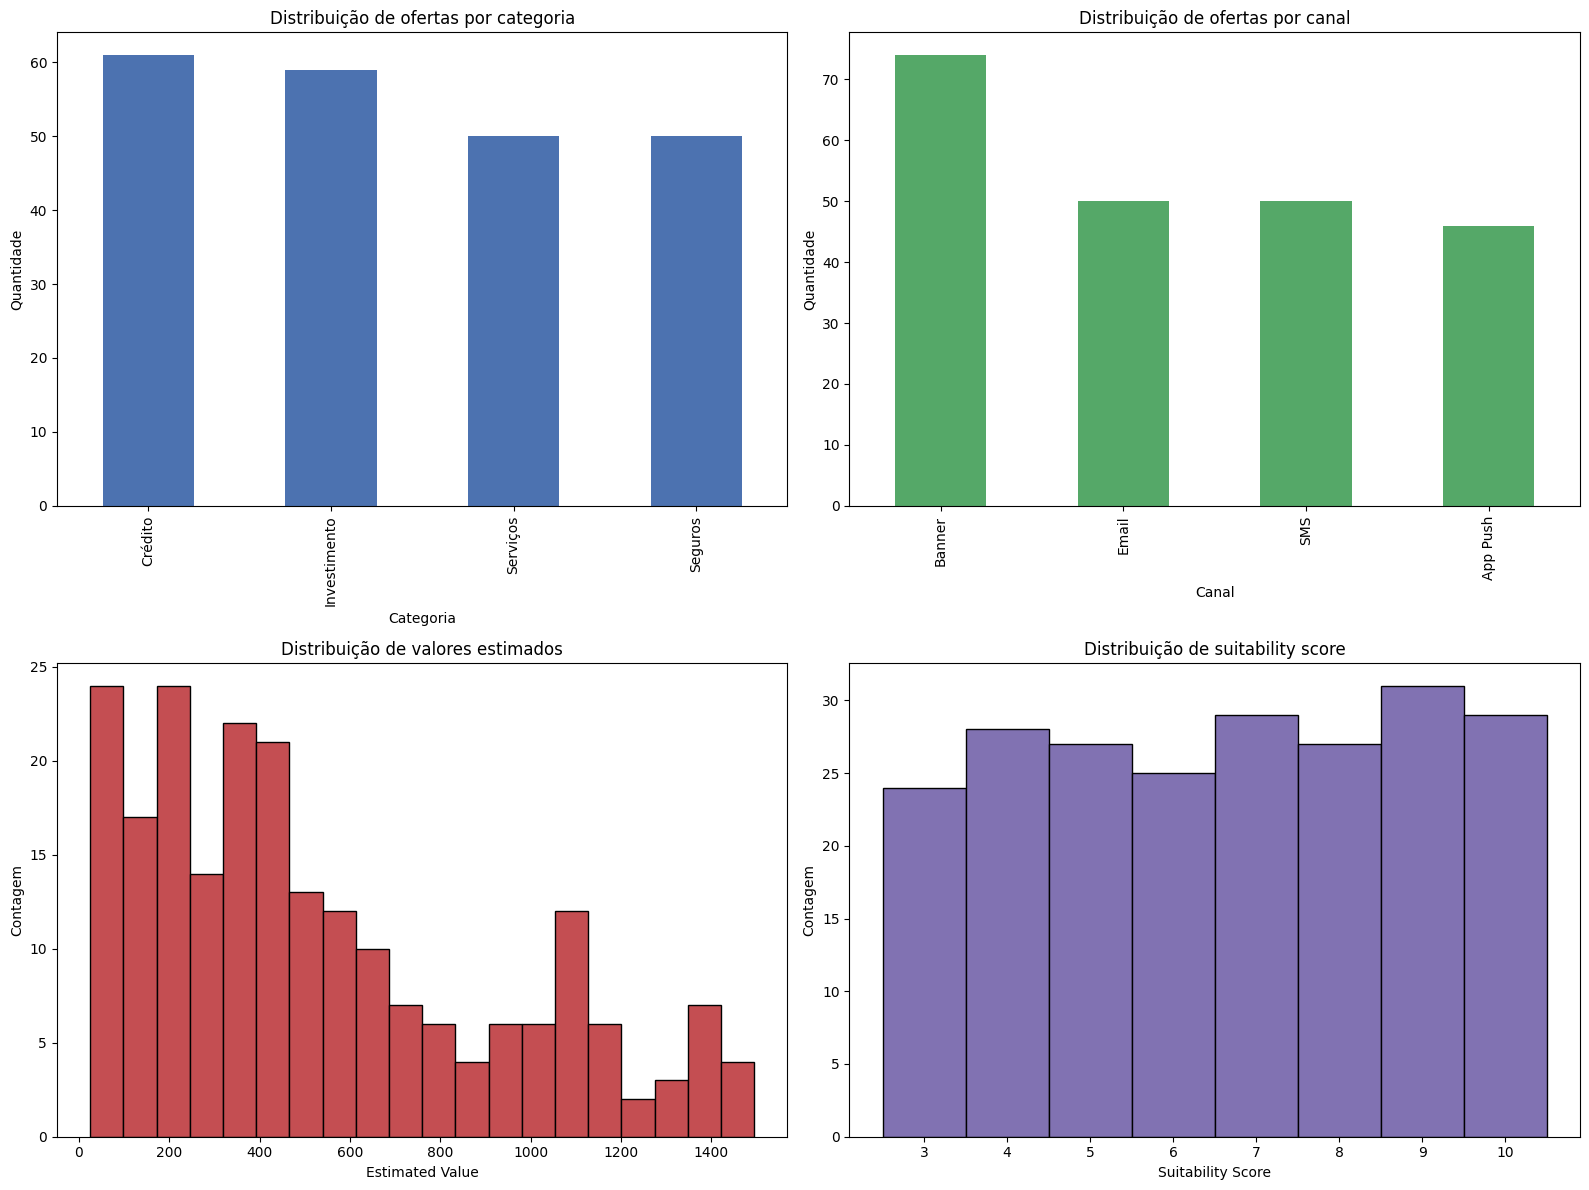

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

file_path = Path('offer_catalog.csv')
df = pd.read_csv(file_path)

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
df['category'].value_counts().plot(kind='bar', color='#4c72b0')
plt.title('Distribuição de ofertas por categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.subplot(2, 2, 2)
df['channel'].value_counts().plot(kind='bar', color='#55a868')
plt.title('Distribuição de ofertas por canal')
plt.xlabel('Canal')
plt.ylabel('Quantidade')

plt.subplot(2, 2, 3)
plt.hist(df['estimated_value'], bins=20, color='#c44e52', edgecolor='black')
plt.title('Distribuição de valores estimados')
plt.xlabel('Estimated Value')
plt.ylabel('Contagem')

plt.subplot(2, 2, 4)
plt.hist(df['suitability_score'], bins=range(int(df['suitability_score'].min()), int(df['suitability_score'].max()) + 2), color='#8172b2', edgecolor='black', align='left')
plt.title('Distribuição de suitability score')
plt.xlabel('Suitability Score')
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()


## Geração de eventos de ofertas.

Processo de Geração: Os eventos (offer_events.csv) foram gerados iterando sobre a base de usuários tratada. Atribuímos ofertas de forma uniforme (simulando uma fase puramente exploratória) e calculamos a probabilidade de clique usando variáveis da base original adicionadas de ruído gaussiano.

Sementes Aleatórias: Foi utilizada a semente global 42 na biblioteca numpy e random para garantir a reprodutibilidade dos eventos de impressão, contexto de decisão e recompensas intermediárias.  

Horizonte Temporal: A modelagem de delayed rewards e do horizonte temporal foi definida para simular interações entre 01/05/2026 e 30/05/2026.

Colunas geradas:
- event_id
- user_id
- timestamp
- offer_id
- context_segment (derivado do K-cluster (ainda não claramente identificado))
- is_clicked